1. Baseline Setup

In [2]:
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader

#we have to scale up the small cifar10 images to match resnet152 input size and normalize
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) #took these from resnet docs
])

#loading the dataset train and validation seperately
train_dataset = datasets.CIFAR10(root='/kaggle/input/datasets/shehryarasiflone/cifar-10-python-tar-gz', train=True, download=True, transform=transform)
val_dataset = datasets.CIFAR10(root='/kaggle/input/datasets/shehryarasiflone/cifar-10-python-tar-gz', train=False, download=True, transform=transform)

#want to feed the data in batches as more efficient
train_loader = DataLoader(train_dataset, batch_size=30, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=30, shuffle=False)

In [3]:
#setting up the resnet pretrained model
import torchvision.models as models
model = models.resnet152(weights=models.ResNet152_Weights.DEFAULT)

#we dont want the convolution layer parameters to be trained (so freezing the backbone)
for param in model.parameters():
    param.requires_grad = False

#we need to replace the final classification layer
import torch.nn as nn

#first figure out how many features are coming out of the resnet
in_features = model.fc.in_features
#replace the layer with one that outputs 10 classes according to cifr10
model.fc = nn.Linear(in_features, 10)

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 193MB/s]  


In [4]:
#optimiser and loss function
import torch.optim as optim
import torch.nn as nn
#cross entropy chosen as loss function cuz a multiclass classification problem
criterion = nn.CrossEntropyLoss()
#only need the final layer parameters to be passed as rest frozen
#used adam cuz best immediate choice
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [15]:
#training and validation
import torch
#just to make sure colab uses gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
#randomly selected as few as possible to decrease time
epochs = 4

for epoch in range(epochs):
    #training
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() #clearing old grads
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss=train_loss+loss.item()

        #calculating best training accuracy
        _, predicted = torch.max(outputs, 1)
        train_total=train_total+labels.size(0)
        train_correct=train_correct+(predicted == labels).sum().item()

    avg_train_loss = train_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total

    #validating
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    #no grad tracking to save time
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            # Calculate validation accuracy
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total

    #final performance
    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_accuracy:.2f}%")
    print(f"Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_accuracy:.2f}%")

Epoch [1/4]
Train Loss: 0.4383 | Train Acc: 85.13%
Val Loss:   0.4715 | Val Acc:   84.22%
Epoch [2/4]
Train Loss: 0.4294 | Train Acc: 85.38%
Val Loss:   0.4702 | Val Acc:   84.37%
Epoch [3/4]
Train Loss: 0.4180 | Train Acc: 85.71%
Val Loss:   0.4729 | Val Acc:   84.34%
Epoch [4/4]
Train Loss: 0.4109 | Train Acc: 85.87%
Val Loss:   0.4691 | Val Acc:   84.75%


2. Residual Connections

In [ ]:
#funtion to remove res connections manually
def disable_skip(block):
    def forward_without_skip(x):
        out = block.conv1(x)
        out = block.bn1(out)
        out = block.relu(out)

        out = block.conv2(out)
        out = block.bn2(out)
        out = block.relu(out)

        out = block.conv3(out)
        out = block.bn3(out)

        out = block.relu(out)
        return out

    block.forward = forward_without_skip

#have applied to all blocks in layer 4
disable_skip(model.layer4[0])
disable_skip(model.layer4[1])
disable_skip(model.layer4[2])
#we need a new haed so that old one isnt used
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, 10)
model.to(device)

#a new optimizer for the new head wiht the same parameters
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

In [ ]:
#exact same training and validation setup as baseline
epochs = 4

for epoch in range(epochs):
    #training
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() #clearing old grads
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss=train_loss+loss.item()

        #calculating best training accuracy
        _, predicted = torch.max(outputs, 1)
        train_total=train_total+labels.size(0)
        train_correct=train_correct+(predicted == labels).sum().item()

    avg_train_loss = train_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total

    #validating
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    #no grad tracking to save time
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            # Calculate validation accuracy
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total

    #final performance
    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_accuracy:.2f}%")
    print(f"Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_accuracy:.2f}%")

Epoch [1/4]
Train Loss: 2.1607 | Train Acc: 27.05%
Val Loss:   2.0803 | Val Acc:   31.04%
Epoch [2/4]
Train Loss: 2.0273 | Train Acc: 32.43%
Val Loss:   1.9929 | Val Acc:   33.68%
Epoch [3/4]
Train Loss: 1.9708 | Train Acc: 33.78%
Val Loss:   1.9922 | Val Acc:   32.59%
Epoch [4/4]
Train Loss: 1.9285 | Train Acc: 34.85%
Val Loss:   1.9511 | Val Acc:   33.79%


3. Feature Hierarchies and Representations

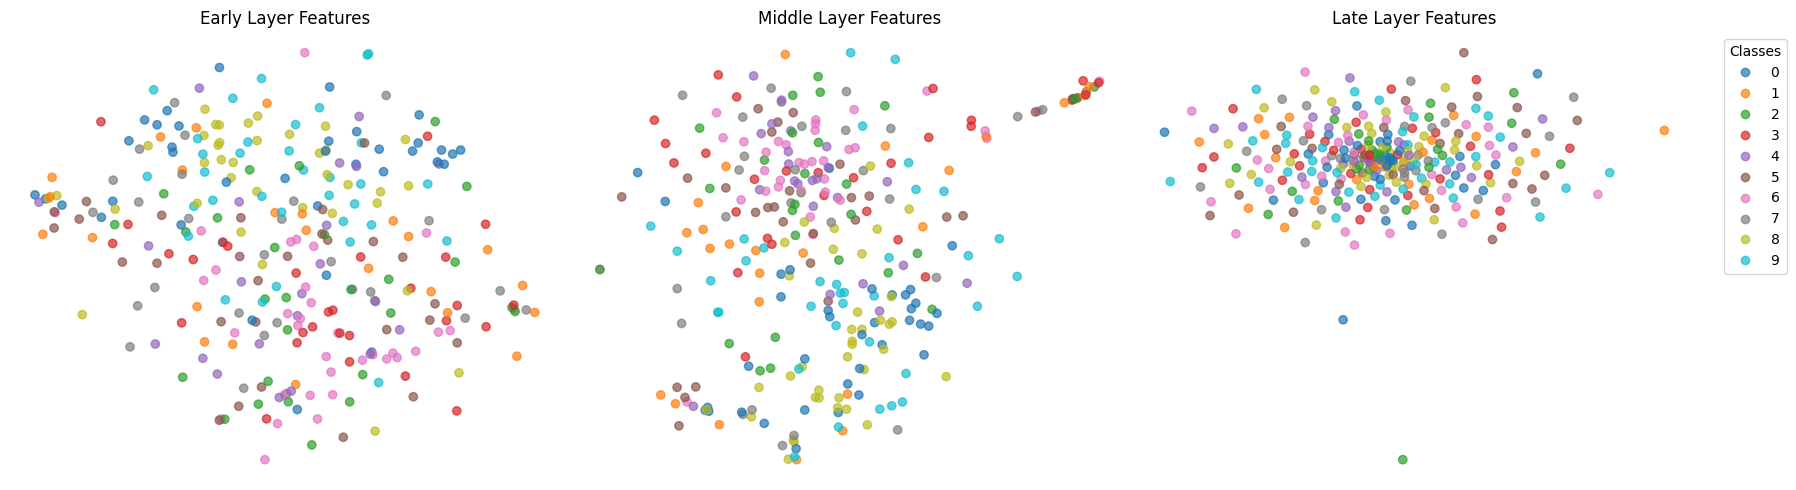

In [18]:
#empty dict so I can store the extracted features
features = {}
#hook function that extracts the parameters and flattens to a 1d array
def get_features(name):
    def hook(model, input, output):
        features[name] = output.detach().cpu().numpy().reshape(output.size(0), -1)
    return hook

#attach hooks to early, middle and late layer
handle_early = model.layer1[0].register_forward_hook(get_features('early'))
handle_middle = model.layer3[0].register_forward_hook(get_features('middle'))
handle_late = model.layer4[-1].register_forward_hook(get_features('late'))

model.eval()

#we get 300 images so that analysis can actually be fruitful
all_inputs = []
all_labels = []

for i, (inputs, labels) in enumerate(val_loader):
    all_inputs.append(inputs)
    all_labels.append(labels)
    if i == 9:  # Stop after gathering 10 batches
        break

#combined to large tensors
inputs = torch.cat(all_inputs).to(device)
labels = torch.cat(all_labels).cpu().numpy()

#paas the data so hook can grab parameters
with torch.no_grad():
    _ = model(inputs)

#remove hooks for cleanup
handle_early.remove()
handle_middle.remove()
handle_late.remove()

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

#initialising the visualisation object with a 2d output requirement
tsne = TSNE(n_components=2, random_state=14)

#figure creation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
layer_names = ['early', 'middle', 'late']

for i, name in enumerate(layer_names):
    #running the object on the features and plotting
    tsne_results = tsne.fit_transform(features[name])
    scatter = axes[i].scatter(tsne_results[:, 0], tsne_results[:, 1], c=labels, cmap='tab10', alpha=0.7)
    axes[i].set_title(f'{name.capitalize()} Layer Features')
    axes[i].axis('off')

#legend for clarity
plt.legend(*scatter.legend_elements(), title="Classes", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

4. Transfer Learning and Generalization

In [19]:
#reinitializing the model with random weights
model_random = models.resnet152(weights=None)

in_features = model_random.fc.in_features
model_random.fc = nn.Linear(in_features, 10)
model_random.to(device)

#setting up theoptimizer but passing all parameters not just the final classification layer
optimizer_random = optim.Adam(model_random.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [20]:
#exact same training and validation setup as baseline
epochs = 4

for epoch in range(epochs):
    #training
    model_random.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_random.zero_grad() #clearing old grads
        outputs = model_random(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_random.step()

        train_loss=train_loss+loss.item()

        #calculating best training accuracy
        _, predicted = torch.max(outputs, 1)
        train_total=train_total+labels.size(0)
        train_correct=train_correct+(predicted == labels).sum().item()

    avg_train_loss = train_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total

    #validating
    model_random.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    #no grad tracking to save time
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model_random(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            # Calculate validation accuracy
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total

    #final performance
    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_accuracy:.2f}%")
    print(f"Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_accuracy:.2f}%")

Epoch [1/4]
Train Loss: 1.7947 | Train Acc: 32.43%
Val Loss:   1.5204 | Val Acc:   41.74%
Epoch [2/4]
Train Loss: 1.3451 | Train Acc: 50.61%
Val Loss:   1.3205 | Val Acc:   52.51%
Epoch [3/4]
Train Loss: 1.0188 | Train Acc: 63.88%
Val Loss:   1.2351 | Val Acc:   59.23%
Epoch [4/4]
Train Loss: 0.8301 | Train Acc: 70.90%
Val Loss:   0.7714 | Val Acc:   73.23%


In [8]:
#training final block and freezing the rest
model_final_block = models.resnet152(weights=models.ResNet152_Weights.DEFAULT)

#first have to freeze all layers
for param in model_final_block.parameters():
    param.requires_grad = False

#then only freeze last layer (4) and the fc layer
for param in model_final_block.layer4.parameters():
    param.requires_grad = True
in_features = model_final_block.fc.in_features
model_final_block.fc = nn.Linear(in_features, 10)
criterion = nn.CrossEntropyLoss()

In [13]:
#exact same training and validation setup as baseline
epochs = 4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_final_block.to(device)
#we need to add a filter before passing frozen parameters to optim
optimizer_final_block = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_final_block.parameters()), 
    lr=0.001
)
for epoch in range(epochs):
    #training
    model_final_block.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_final_block.zero_grad() #clearing old grads
        outputs = model_final_block(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_final_block.step()

        train_loss=train_loss+loss.item()

        #calculating best training accuracy
        _, predicted = torch.max(outputs, 1)
        train_total=train_total+labels.size(0)
        train_correct=train_correct+(predicted == labels).sum().item()

    avg_train_loss = train_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total

    #validating
    model_final_block.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    #no grad tracking to save time
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model_final_block(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            # Calculate validation accuracy
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total

    #final performance
    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_accuracy:.2f}%")
    print(f"Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_accuracy:.2f}%")

Epoch [1/4]
Train Loss: 0.3967 | Train Acc: 86.74%
Val Loss:   0.2924 | Val Acc:   90.43%
Epoch [2/4]
Train Loss: 0.1976 | Train Acc: 93.19%
Val Loss:   0.2426 | Val Acc:   91.71%
Epoch [3/4]
Train Loss: 0.1177 | Train Acc: 95.86%
Val Loss:   0.2430 | Val Acc:   92.54%
Epoch [4/4]
Train Loss: 0.0772 | Train Acc: 97.30%
Val Loss:   0.2606 | Val Acc:   92.35%


In [5]:
#training full backbone with weights initialized
model_full = models.resnet152(weights=models.ResNet152_Weights.DEFAULT)
in_features = model_full.fc.in_features
model_full.fc = nn.Linear(in_features, 10)
model_full.to(device)
criterion = nn.CrossEntropyLoss()

In [6]:
#exact same training and validation setup as baseline
epochs = 4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_full.to(device)
#the optimizer takes all parameters and i use a smaller rate as is practice for
#this method
optimizer_full = optim.Adam(model_full.parameters(), lr=0.0005)
for epoch in range(epochs):
    #training
    model_full.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_full.zero_grad() #clearing old grads
        outputs = model_full(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_full.step()

        train_loss=train_loss+loss.item()

        #calculating best training accuracy
        _, predicted = torch.max(outputs, 1)
        train_total=train_total+labels.size(0)
        train_correct=train_correct+(predicted == labels).sum().item()

    avg_train_loss = train_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total

    #validating
    model_full.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    #no grad tracking to save time
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model_full(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            # Calculate validation accuracy
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total

    #final performance
    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_accuracy:.2f}%")
    print(f"Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_accuracy:.2f}%")

Epoch [1/4]
Train Loss: 0.4173 | Train Acc: 86.19%
Val Loss:   0.2804 | Val Acc:   90.35%
Epoch [2/4]
Train Loss: 0.2373 | Train Acc: 91.96%
Val Loss:   0.2743 | Val Acc:   90.57%
Epoch [3/4]
Train Loss: 0.1685 | Train Acc: 94.19%
Val Loss:   0.2036 | Val Acc:   93.12%
Epoch [4/4]
Train Loss: 0.1308 | Train Acc: 95.48%
Val Loss:   0.2261 | Val Acc:   92.59%
